<a href="https://colab.research.google.com/github/IngridCEK/Document-Intelligence-Service/blob/main/Training%20the%20embedding%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch transformers datasets sentence-transformers scipy numpy matplotlib tqdm

In [1]:
import torch
import numpy as np
from datasets import load_dataset
from scipy.stats import spearmanr
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

# 1. Función para calcular pooling medio (Mean Pooling) para modelos HuggingFace
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] # Primer elemento contiene todos los token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# 2. Función de evaluación para un modelo de Transformers estándar (bert-base-uncased)
def evaluate_hf_model(model_name="bert-base-uncased", device="cuda" if torch.cuda.is_available() else "cpu"):
    print(f"\n--- Evaluando modelo HF: {model_name} ---")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    stsb = load_dataset("sentence-transformers/stsb")

    for split in ["validation", "test"]: # validation = dev
        sentences1 = stsb[split]["sentence1"]
        sentences2 = stsb[split]["sentence2"]
        labels = stsb[split]["score"]

        embeddings1, embeddings2 = [], []

        with torch.no_grad():
            for i in range(0, len(sentences1), 64):
                batch1 = sentences1[i:i+64]
                batch2 = sentences2[i:i+64]

                # Process sentences 1
                encoded1 = tokenizer(batch1, padding=True, truncation=True, return_tensors="pt").to(device)
                out1 = model(**encoded1)
                emb1 = mean_pooling(out1, encoded1["attention_mask"])
                embeddings1.append(emb1.cpu())

                # Process sentences 2
                encoded2 = tokenizer(batch2, padding=True, truncation=True, return_tensors="pt").to(device)
                out2 = model(**encoded2)
                emb2 = mean_pooling(out2, encoded2["attention_mask"])
                embeddings2.append(emb2.cpu())

        embeddings1 = torch.cat(embeddings1, dim=0)
        embeddings2 = torch.cat(embeddings2, dim=0)

        # Similitud de Coseno
        cos_sim = torch.nn.functional.cosine_similarity(embeddings1, embeddings2)

        # Correlación de Spearman (convertida a escala 0-100 para coincidir con la especificación)
        spearman_corr, _ = spearmanr(cos_sim.numpy(), labels)
        print(f"Split {split.upper()} - Spearman Correlation: {spearman_corr * 100:.2f}")

# 3. Función de evaluación para SBERT (SentenceTransformers)
def evaluate_sbert_model(model_name="sentence-transformers/bert-base-nli-mean-tokens"):
    print(f"\n--- Evaluando modelo SBERT: {model_name} ---")
    model = SentenceTransformer(model_name)
    stsb = load_dataset("sentence-transformers/stsb")

    for split in ["validation", "test"]:
        sentences1 = stsb[split]["sentence1"]
        sentences2 = stsb[split]["sentence2"]
        labels = stsb[split]["score"]

        emb1 = model.encode(sentences1, convert_to_tensor=True)
        emb2 = model.encode(sentences2, convert_to_tensor=True)

        cos_sim = torch.nn.functional.cosine_similarity(emb1, emb2).cpu().numpy()
        spearman_corr, _ = spearmanr(cos_sim, labels)
        print(f"Split {split.upper()} - Spearman Correlation: {spearman_corr * 100:.2f}")

if __name__ == "__main__":
    # Evaluar bert-base-uncased
    evaluate_hf_model("bert-base-uncased")

    # Evaluar SBERT-2019
    evaluate_sbert_model("sentence-transformers/bert-base-nli-mean-tokens")


--- Evaluando modelo HF: bert-base-uncased ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Split VALIDATION - Spearman Correlation: 59.31
Split TEST - Spearman Correlation: 47.29

--- Evaluando modelo SBERT: sentence-transformers/bert-base-nli-mean-tokens ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Split VALIDATION - Spearman Correlation: 80.77
Split TEST - Spearman Correlation: 76.98


**SCRIPT DE ENTRENAMIENTO NO SUPERVISADO**

In [2]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from scipy.stats import spearmanr
import numpy as np

# Configuración de Hiperparámetros (según paper / especificaciones)
MODEL_NAME = "bert-base-uncased"
BATCH_SIZE = 64
LR = 3e-5
EPOCHS = 1
TEMP = 0.05
MAX_LEN = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Utilizando dispositivo: {DEVICE}")


# 1. Cargar oraciones únicas de SNLI
def load_unsup_data(filepath="/content/snli_train_100k.jsonl"):
    sentences = set()

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)

            # El archivo utiliza las claves "premise" y "hypothesis"
            if "premise" in data and data["premise"]:
                sentences.add(data["premise"].strip())

            if "hypothesis" in data and data["hypothesis"]:
                sentences.add(data["hypothesis"].strip())

    print(f"Oraciones únicas cargadas para No Supervisado: {len(sentences)}")

    return list(sentences)


class UnsupDataset(Dataset):
    def __init__(self, sentences):
        self.sentences = sentences

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return self.sentences[idx]


# 2. Modelo SimCSE No Supervisado
class SimCSEUnsupervised(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Usamos el token [CLS] (posición 0) como embedding
        return outputs.last_hidden_state[:, 0, :]


# 3. Pérdida Contrastiva (InfoNCE / Cross Entropy de N vías)
def contrastive_loss(emb1, emb2, temp=TEMP):
    emb1 = nn.functional.normalize(emb1, dim=1)
    emb2 = nn.functional.normalize(emb2, dim=1)

    cos_sim = torch.mm(emb1, emb2.T) / temp

    labels = torch.arange(
        cos_sim.size(0)
    ).long().to(cos_sim.device)

    loss_fct = nn.CrossEntropyLoss()

    loss = loss_fct(cos_sim, labels)

    return loss


# 4. Función de Evaluación en STS-B
def evaluate_stsb(model, tokenizer, split="validation"):
    model.eval()

    stsb = load_dataset("sentence-transformers/stsb")

    sentences1 = stsb[split]["sentence1"]
    sentences2 = stsb[split]["sentence2"]
    labels = stsb[split]["score"]

    embeddings1, embeddings2 = [], []

    with torch.no_grad():

        for i in range(0, len(sentences1), 64):

            b1 = sentences1[i:i+64]
            b2 = sentences2[i:i+64]

            enc1 = tokenizer(
                b1,
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            ).to(DEVICE)

            enc2 = tokenizer(
                b2,
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            ).to(DEVICE)

            emb1 = nn.functional.normalize(
                model(
                    enc1["input_ids"],
                    enc1["attention_mask"]
                ),
                dim=1
            )

            emb2 = nn.functional.normalize(
                model(
                    enc2["input_ids"],
                    enc2["attention_mask"]
                ),
                dim=1
            )

            embeddings1.append(emb1.cpu())
            embeddings2.append(emb2.cpu())

    embeddings1 = torch.cat(embeddings1, dim=0)
    embeddings2 = torch.cat(embeddings2, dim=0)

    cos_sim = nn.functional.cosine_similarity(
        embeddings1,
        embeddings2
    )

    spearman_corr, _ = spearmanr(
        cos_sim.numpy(),
        labels
    )

    return spearman_corr * 100


# 5. Pipeline de Entrenamiento
def train_unsup():

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # Cargar el archivo que subiste a Google Colab
    sentences = load_unsup_data(
        "/content/snli_train_100k.jsonl"
    )

    dataset = UnsupDataset(sentences)

    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

    model = SimCSEUnsupervised().to(DEVICE)

    optimizer = AdamW(
        model.parameters(),
        lr=LR
    )

    total_steps = len(dataloader) * EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    best_spearman = 0.0

    print("\n--- Iniciando Entrenamiento SimCSE No Supervisado ---")

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for step, batch in enumerate(dataloader):

            inputs1 = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            ).to(DEVICE)

            inputs2 = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            ).to(DEVICE)

            emb1 = model(
                inputs1["input_ids"],
                inputs1["attention_mask"]
            )

            emb2 = model(
                inputs2["input_ids"],
                inputs2["attention_mask"]
            )

            loss = contrastive_loss(
                emb1,
                emb2
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            scheduler.step()

            total_loss += loss.item()

            if (
                (step + 1) % 500 == 0
                or (step + 1) == len(dataloader)
            ):

                print(
                    f"Época [{epoch+1}/{EPOCHS}] | "
                    f"Paso [{step+1}/{len(dataloader)}] | "
                    f"Loss: {total_loss / (step + 1):.4f}"
                )

        # Evaluación en STS-B
        val_spearman = evaluate_stsb(
            model,
            tokenizer,
            split="validation"
        )

        print(
            f"\n---> Época {epoch+1} - "
            f"STS-B Validation Spearman: {val_spearman:.2f}"
        )

        if val_spearman > best_spearman:

            best_spearman = val_spearman

            torch.save(
                model.state_dict(),
                "simcse_unsup_best.pt"
            )

            print(
                "¡Nuevo mejor modelo guardado "
                "en 'simcse_unsup_best.pt'!"
            )

    print("\n--- Evaluación Final en Set de Test ---")

    # Modificado aquí para evitar la advertencia de PyTorch
    model.load_state_dict(
        torch.load(
            "simcse_unsup_best.pt",
            weights_only=True
        )
    )

    test_spearman = evaluate_stsb(
        model,
        tokenizer,
        split="test"
    )

    print(
        f" SimCSE No Supervisado TEST "
        f"Spearman: {test_spearman:.2f}"
    )


# 6. Ejecutar entrenamiento
if __name__ == "__main__":
    train_unsup()

Utilizando dispositivo: cuda
Oraciones únicas cargadas para No Supervisado: 165528


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Iniciando Entrenamiento SimCSE No Supervisado ---
Época [1/1] | Paso [500/2586] | Loss: 0.1210
Época [1/1] | Paso [1000/2586] | Loss: 0.0612
Época [1/1] | Paso [1500/2586] | Loss: 0.0411
Época [1/1] | Paso [2000/2586] | Loss: 0.0310
Época [1/1] | Paso [2500/2586] | Loss: 0.0249
Época [1/1] | Paso [2586/2586] | Loss: 0.0241

---> Época 1 - STS-B Validation Spearman: 74.25
¡Nuevo mejor modelo guardado en 'simcse_unsup_best.pt'!

--- Evaluación Final en Set de Test ---
 SimCSE No Supervisado TEST Spearman: 65.98


**ENTRENAMIENTO SUPERVISADO**

In [3]:
import json
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from scipy.stats import spearmanr
from collections import defaultdict
import numpy as np

# Configuración de Hiperparámetros
MODEL_NAME = "bert-base-uncased"
BATCH_SIZE = 64
LR = 5e-5
EPOCHS = 1
TEMP = 0.05
MAX_LEN = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Utilizando dispositivo: {DEVICE}")


# 1. Cargar y construir Triplets adaptado a etiquetas numéricas (0: entailment, 2: contradiction)
def load_sup_data(filepath="/content/snli_train_100k.jsonl"):
    premise_map = defaultdict(lambda: {"entailment": [], "contradiction": []})
    all_contradictions = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            data = json.loads(line)

            premise = str(data.get("premise", "")).strip()
            hypothesis = str(data.get("hypothesis", "")).strip()
            label = data.get("label")

            # Mapeo: 0 -> entailment (positivo), 2 -> contradiction (negativo duro)
            if premise and hypothesis:
                if label == 0 or label == "0" or label == "entailment":
                    premise_map[premise]["entailment"].append(hypothesis)
                elif label == 2 or label == "2" or label == "contradiction":
                    premise_map[premise]["contradiction"].append(hypothesis)
                    all_contradictions.append(hypothesis)

    triplets = []
    # Construcción de triplets para cada combinación (Premisa + Entailment)
    for premise, preds in premise_map.items():
        if preds["entailment"]:
            for pos in preds["entailment"]:
                if preds["contradiction"]:
                    neg = preds["contradiction"][0]
                elif all_contradictions:
                    neg = random.choice(all_contradictions)
                else:
                    neg = pos

                triplets.append((premise, pos, neg))

    print(f"Triplets construidos para Supervisado: {len(triplets)}")
    return triplets


class SupDataset(Dataset):
    def __init__(self, triplets):
        self.triplets = triplets

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        return self.triplets[idx]


# 2. Modelo SimCSE Supervisado
class SimCSESupervised(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        return outputs.last_hidden_state[:, 0, :]


# 3. Pérdida Contrastiva Supervisada con Hard Negatives
def supervised_contrastive_loss(emb_anc, emb_pos, emb_neg, temp=TEMP):
    emb_anc = nn.functional.normalize(emb_anc, dim=1)
    emb_pos = nn.functional.normalize(emb_pos, dim=1)
    emb_neg = nn.functional.normalize(emb_neg, dim=1)

    emb_targets = torch.cat([emb_pos, emb_neg], dim=0)
    cos_sim = torch.mm(emb_anc, emb_targets.T) / temp

    labels = torch.arange(cos_sim.size(0)).long().to(cos_sim.device)

    loss_fct = nn.CrossEntropyLoss()
    return loss_fct(cos_sim, labels)


# 4. Función de Evaluación en STS-B
def evaluate_stsb(model, tokenizer, split="validation"):
    model.eval()
    stsb = load_dataset("sentence-transformers/stsb")

    sentences1 = stsb[split]["sentence1"]
    sentences2 = stsb[split]["sentence2"]
    labels = stsb[split]["score"]

    embeddings1, embeddings2 = [], []

    with torch.no_grad():
        for i in range(0, len(sentences1), 64):
            b1 = sentences1[i:i+64]
            b2 = sentences2[i:i+64]

            enc1 = tokenizer(
                b1, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt"
            ).to(DEVICE)
            enc2 = tokenizer(
                b2, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt"
            ).to(DEVICE)

            emb1 = nn.functional.normalize(
                model(enc1["input_ids"], enc1["attention_mask"]), dim=1
            )
            emb2 = nn.functional.normalize(
                model(enc2["input_ids"], enc2["attention_mask"]), dim=1
            )

            embeddings1.append(emb1.cpu())
            embeddings2.append(emb2.cpu())

    embeddings1 = torch.cat(embeddings1, dim=0)
    embeddings2 = torch.cat(embeddings2, dim=0)

    cos_sim = nn.functional.cosine_similarity(embeddings1, embeddings2)
    spearman_corr, _ = spearmanr(cos_sim.numpy(), labels)
    return spearman_corr * 100


# 5. Pipeline de Entrenamiento Supervisado
def train_sup():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    triplets = load_sup_data("/content/snli_train_100k.jsonl")

    dataset = SupDataset(triplets)
    dataloader = DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
    )

    model = SimCSESupervised().to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR)

    total_steps = len(dataloader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    best_spearman = 0.0

    print("\n--- Iniciando Entrenamiento SimCSE Supervisado ---")
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for step, (anc, pos, neg) in enumerate(dataloader):
            enc_anc = tokenizer(
                list(anc), padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt"
            ).to(DEVICE)
            enc_pos = tokenizer(
                list(pos), padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt"
            ).to(DEVICE)
            enc_neg = tokenizer(
                list(neg), padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt"
            ).to(DEVICE)

            emb_anc = model(enc_anc["input_ids"], enc_anc["attention_mask"])
            emb_pos = model(enc_pos["input_ids"], enc_pos["attention_mask"])
            emb_neg = model(enc_neg["input_ids"], enc_neg["attention_mask"])

            loss = supervised_contrastive_loss(emb_anc, emb_pos, emb_neg)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

            if (step + 1) % 200 == 0 or (step + 1) == len(dataloader):
                print(
                    f"Época [{epoch+1}/{EPOCHS}] | "
                    f"Paso [{step+1}/{len(dataloader)}] | "
                    f"Loss: {total_loss / (step + 1):.4f}"
                )

        # Evaluación en Validation
        val_spearman = evaluate_stsb(model, tokenizer, split="validation")
        print(f"\n---> Época {epoch+1} - STS-B Validation Spearman: {val_spearman:.2f}")

        if val_spearman > best_spearman:
            best_spearman = val_spearman
            torch.save(model.state_dict(), "simcse_sup_best.pt")
            print("¡Nuevo mejor modelo guardado en 'simcse_sup_best.pt'!")

    print("\n--- Evaluación Final en Set de Test ---")
    model.load_state_dict(torch.load("simcse_sup_best.pt", weights_only=True))
    test_spearman = evaluate_stsb(model, tokenizer, split="test")
    print(f" SimCSE Supervisado TEST Spearman: {test_spearman:.2f}")


if __name__ == "__main__":
    train_sup()

Utilizando dispositivo: cuda
Triplets construidos para Supervisado: 33351


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Iniciando Entrenamiento SimCSE Supervisado ---
Época [1/1] | Paso [200/521] | Loss: 1.2036
Época [1/1] | Paso [400/521] | Loss: 0.9248
Época [1/1] | Paso [521/521] | Loss: 0.8512

---> Época 1 - STS-B Validation Spearman: 81.95
¡Nuevo mejor modelo guardado en 'simcse_sup_best.pt'!

--- Evaluación Final en Set de Test ---
 SimCSE Supervisado TEST Spearman: 78.09


**primero la Ablación No Supervisada y luego la Ablación Supervisada**

In [4]:
import json
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from scipy.stats import spearmanr
from collections import defaultdict
import numpy as np

# Configuración de Hiperparámetros base
MODEL_NAME = "bert-base-uncased"
BATCH_SIZE = 64
LR_UNSUP = 3e-5
LR_SUP = 5e-5
EPOCHS = 1
TEMP = 0.05
MAX_LEN = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Utilizando dispositivo: {DEVICE}")

# ---------------------------------------------------------
# FUNCIONES DE CARGA Y EVALUACIÓN
# ---------------------------------------------------------
def load_unsup_data(filepath="/content/snli_train_100k.jsonl"):
    sentences = set()
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip(): continue
            data = json.loads(line)
            if "premise" in data and data["premise"]: sentences.add(data["premise"].strip())
            if "hypothesis" in data and data["hypothesis"]: sentences.add(data["hypothesis"].strip())
    return list(sentences)

def load_sup_data(filepath="/content/snli_train_100k.jsonl"):
    premise_map = defaultdict(lambda: {"entailment": [], "contradiction": []})
    all_contradictions = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip(): continue
            data = json.loads(line)
            premise = str(data.get("premise", "")).strip()
            hypothesis = str(data.get("hypothesis", "")).strip()
            label = data.get("label")
            if premise and hypothesis:
                if label == 0 or label == "0" or label == "entailment":
                    premise_map[premise]["entailment"].append(hypothesis)
                elif label == 2 or label == "2" or label == "contradiction":
                    premise_map[premise]["contradiction"].append(hypothesis)
                    all_contradictions.append(hypothesis)
    triplets = []
    for premise, preds in premise_map.items():
        if preds["entailment"]:
            for pos in preds["entailment"]:
                neg = preds["contradiction"][0] if preds["contradiction"] else (random.choice(all_contradictions) if all_contradictions else pos)
                triplets.append((premise, pos, neg))
    return triplets

class GenericDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

class SimCSEModel(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state[:, 0, :]

def evaluate_stsb(model, tokenizer, split="validation"):
    model.eval()
    stsb = load_dataset("sentence-transformers/stsb")
    sentences1, sentences2, labels = stsb[split]["sentence1"], stsb[split]["sentence2"], stsb[split]["score"]
    embeddings1, embeddings2 = [], []
    with torch.no_grad():
        for i in range(0, len(sentences1), 64):
            b1, b2 = sentences1[i:i+64], sentences2[i:i+64]
            enc1 = tokenizer(b1, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
            enc2 = tokenizer(b2, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
            emb1 = nn.functional.normalize(model(enc1["input_ids"], enc1["attention_mask"]), dim=1)
            emb2 = nn.functional.normalize(model(enc2["input_ids"], enc2["attention_mask"]), dim=1)
            embeddings1.append(emb1.cpu())
            embeddings2.append(emb2.cpu())
    embeddings1, embeddings2 = torch.cat(embeddings1, dim=0), torch.cat(embeddings2, dim=0)
    cos_sim = nn.functional.cosine_similarity(embeddings1, embeddings2)
    spearman_corr, _ = spearmanr(cos_sim.numpy(), labels)
    return spearman_corr * 100

# ---------------------------------------------------------
# 1. ABLACIÓN NO SUPERVISADA (Misma máscara de Dropout)
# ---------------------------------------------------------
def run_ablation_unsup():
    print("\n=======================================================")
    print("INICIANDO ABLACIÓN 1: NO SUPERVISADO (Misma Máscara de Dropout)")
    print("=======================================================")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    sentences = load_unsup_data("/content/snli_train_100k.jsonl")
    dataloader = DataLoader(GenericDataset(sentences), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    model = SimCSEModel().to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR_UNSUP)
    total_steps = len(dataloader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps*0.1), num_training_steps=total_steps)

    model.train()
    for step, batch in enumerate(dataloader):
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)

        # ABLACIÓN: Usamos el mismo pase hacia adelante (misma máscara de dropout) duplicando los embeddings
        emb1 = model(inputs["input_ids"], inputs["attention_mask"])
        emb2 = emb1.clone() # Sin dropout independiente entre dos pasadas

        emb1_norm, emb2_norm = nn.functional.normalize(emb1, dim=1), nn.functional.normalize(emb2, dim=1)
        cos_sim = torch.mm(emb1_norm, emb2_norm.T) / TEMP
        labels = torch.arange(cos_sim.size(0)).long().to(DEVICE)
        loss = nn.CrossEntropyLoss()(cos_sim, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        if (step + 1) % 1000 == 0 or (step + 1) == len(dataloader):
            print(f"Paso [{step+1}/{len(dataloader)}] | Loss: {loss.item():.4f}")

    dev_spearman = evaluate_stsb(model, tokenizer, split="validation")
    test_spearman = evaluate_stsb(model, tokenizer, split="test")
    print(f"\n---> Ablación Unsup Dev Spearman: {dev_spearman:.2f}")
    print(f"  Ablación Unsup TEST Spearman: {test_spearman:.2f}")
    return dev_spearman, test_spearman

# ---------------------------------------------------------
# 2. ABLACIÓN SUPERVISADA (Sin Hard Negatives)
# ---------------------------------------------------------
def run_ablation_sup():
    print("\n=======================================================")
    print("INICIANDO ABLACIÓN 2: SUPERVISADO (Sin Hard Negatives / Solo Positivos)")
    print("=======================================================")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    triplets = load_sup_data("/content/snli_train_100k.jsonl")
    dataloader = DataLoader(GenericDataset(triplets), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    model = SimCSEModel().to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR_SUP)
    total_steps = len(dataloader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps*0.1), num_training_steps=total_steps)

    model.train()
    for step, (anc, pos, _) in enumerate(dataloader): # Ignoramos el negativo duro (neg)
        enc_anc = tokenizer(list(anc), padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        enc_pos = tokenizer(list(pos), padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)

        emb_anc = model(enc_anc["input_ids"], enc_anc["attention_mask"])
        emb_pos = model(enc_pos["input_ids"], enc_pos["attention_mask"])

        # Normalización L2
        emb_anc = nn.functional.normalize(emb_anc, dim=1)
        emb_pos = nn.functional.normalize(emb_pos, dim=1)

        # ABLACIÓN: Solo comparamos Ancla vs Positivos (sin la columna de Hard Negatives)
        cos_sim = torch.mm(emb_anc, emb_pos.T) / TEMP
        labels = torch.arange(cos_sim.size(0)).long().to(DEVICE)
        loss = nn.CrossEntropyLoss()(cos_sim, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        if (step + 1) % 200 == 0 or (step + 1) == len(dataloader):
            print(f"Paso [{step+1}/{len(dataloader)}] | Loss: {loss.item():.4f}")

    dev_spearman = evaluate_stsb(model, tokenizer, split="validation")
    test_spearman = evaluate_stsb(model, tokenizer, split="test")
    print(f"\n---> Ablación Sup (Sin Hard Negatives) Dev Spearman: {dev_spearman:.2f}")
    print(f" Ablación Sup (Sin Hard Negatives) TEST Spearman: {test_spearman:.2f}")
    return dev_spearman, test_spearman

if __name__ == "__main__":
    dev_unsup_abl, test_unsup_abl = run_ablation_unsup()
    dev_sup_abl, test_sup_abl = run_ablation_sup()

    print("\n=======================================================")
    print("RESUMEN DE ABLACIONES (PARTE 5)")
    print("=======================================================")
    print(f"Unsupervised Original: Dev 74.15 | Test 65.82")
    print(f"Unsupervised Ablation (Same Dropout): Dev {dev_unsup_abl:.2f} | Test {test_unsup_abl:.2f}")
    print("---")
    print(f"Supervised Original: Dev 81.89 | Test 78.34")
    print(f"Supervised Ablation (No Hard Negatives): Dev {dev_sup_abl:.2f} | Test {test_sup_abl:.2f}")

Utilizando dispositivo: cuda

INICIANDO ABLACIÓN 1: NO SUPERVISADO (Misma Máscara de Dropout)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Paso [1000/2586] | Loss: 0.0000
Paso [2000/2586] | Loss: 0.0000
Paso [2586/2586] | Loss: 0.0000

---> Ablación Unsup Dev Spearman: 49.63
  Ablación Unsup TEST Spearman: 43.12

INICIANDO ABLACIÓN 2: SUPERVISADO (Sin Hard Negatives / Solo Positivos)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Paso [200/521] | Loss: 0.7895
Paso [400/521] | Loss: 0.3548
Paso [521/521] | Loss: 0.3998

---> Ablación Sup (Sin Hard Negatives) Dev Spearman: 81.52
 Ablación Sup (Sin Hard Negatives) TEST Spearman: 76.65

RESUMEN DE ABLACIONES (PARTE 5)
Unsupervised Original: Dev 74.15 | Test 65.82
Unsupervised Ablation (Same Dropout): Dev 49.63 | Test 43.12
---
Supervised Original: Dev 81.89 | Test 78.34
Supervised Ablation (No Hard Negatives): Dev 81.52 | Test 76.65


**Alignment and Uniformity**

In [5]:
import torch
import torch.nn as nn
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Definición de Métricas según Wang & Isola (2020)
def compute_align_uniform(model, tokenizer, stsb_split="validation"):
    model.eval()
    stsb = load_dataset("sentence-transformers/stsb")[stsb_split]
    sentences1 = stsb["sentence1"]
    sentences2 = stsb["sentence2"]

    emb1_list, emb2_list = [], []
    with torch.no_grad():
        for i in range(0, len(sentences1), 64):
            b1 = sentences1[i:i+64]
            b2 = sentences2[i:i+64]
            enc1 = tokenizer(b1, padding=True, truncation=True, max_length=32, return_tensors="pt").to(DEVICE)
            enc2 = tokenizer(b2, padding=True, truncation=True, max_length=32, return_tensors="pt").to(DEVICE)

            e1 = F.normalize(model(enc1["input_ids"], enc1["attention_mask"]), dim=1)
            e2 = F.normalize(model(enc2["input_ids"], enc2["attention_mask"]), dim=1)

            emb1_list.append(e1)
            emb2_list.append(e2)

    x = torch.cat(emb1_list, dim=0)
    y = torch.cat(emb2_list, dim=0)

    # Alignment: Promedio de ||x_i - y_i||^2 para pares positivos en STS-B (score >= 4.0)
    scores = torch.tensor(stsb["score"]).to(DEVICE)
    high_sim_mask = scores >= 4.0
    if high_sim_mask.sum() > 0:
        align = (x[high_sim_mask] - y[high_sim_mask]).norm(p=2, dim=1).pow(2).mean().item()
    else:
        align = (x - y).norm(p=2, dim=1).pow(2).mean().item()

    # Uniformity: log( E [ exp( -2 * ||x_i - x_j||^2 ) ] )
    all_embs = torch.cat([x, y], dim=0)
    dist_sq = torch.pdist(all_embs, p=2).pow(2)
    uniform = torch.log(torch.exp(-2 * dist_sq).mean()).item()

    return align, uniform

# 2. Cargar modelo Supervisado de prueba
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

class SimCSEModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("bert-base-uncased")
    def forward(self, input_ids, attention_mask):
        return self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]

model_sup = SimCSEModel().to(DEVICE)
model_sup.load_state_dict(torch.load("simcse_sup_best.pt", weights_only=True))

align, uniform = compute_align_uniform(model_sup, tokenizer, stsb_split="test")
print("=======================================================")
print("PARTE 4: MÉTRICAS DE ALIGNMENT & UNIFORMITY (SUPERVISADO)")
print("=======================================================")
print(f" Alignment (más bajo es mejor):   {align:.4f}")
print(f" Uniformity (más negativo es mejor): {uniform:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PARTE 4: MÉTRICAS DE ALIGNMENT & UNIFORMITY (SUPERVISADO)
 Alignment (más bajo es mejor):   0.5924
 Uniformity (más negativo es mejor): -3.1048


**Análisis de Casos de Falla**

In [6]:
# 3. Análisis de Casos de Falla (k-NN) sobre STS-B Test
print("\n=======================================================")
print("PARTE 4: ANÁLISIS DE CASOS DE FALLA (k-NN / STS-B)")
print("=======================================================")

stsb_test = load_dataset("sentence-transformers/stsb")["test"]
sentences1 = stsb_test["sentence1"]
sentences2 = stsb_test["sentence2"]
true_scores = stsb_test["score"]

model_sup.eval()
emb1_list, emb2_list = [], []

with torch.no_grad():
    for i in range(0, len(sentences1), 64):
        b1 = sentences1[i:i+64]
        b2 = sentences2[i:i+64]
        enc1 = tokenizer(b1, padding=True, truncation=True, max_length=32, return_tensors="pt").to(DEVICE)
        enc2 = tokenizer(b2, padding=True, truncation=True, max_length=32, return_tensors="pt").to(DEVICE)

        e1 = F.normalize(model_sup(enc1["input_ids"], enc1["attention_mask"]), dim=1)
        e2 = F.normalize(model_sup(enc2["input_ids"], enc2["attention_mask"]), dim=1)

        emb1_list.append(e1)
        emb2_list.append(e2)

x = torch.cat(emb1_list, dim=0)
y = torch.cat(emb2_list, dim=0)

# Calcular similitud coseno predicha
cos_sims = F.cosine_similarity(x, y).cpu().numpy()

# Buscar el caso con mayor desajuste entre similitud predicha y puntaje real
errors = []
for idx, (s1_text, s2_text, true_s, sim) in enumerate(zip(sentences1, sentences2, true_scores, cos_sims)):
    # Escalar puntaje real de [0, 5] a [0, 1] para comparar directamente con similitud coseno
    norm_score = true_s / 5.0
    error = abs(norm_score - sim)
    errors.append((error, s1_text, s2_text, true_s, sim))

# Ordenar por el mayor error absoluto
errors.sort(key=lambda item: item[0], reverse=True)
top_failure = errors[0]

print(f"Oración 1: {top_failure[1]}")
print(f"Oración 2: {top_failure[2]}")
print(f"Puntaje Real STS-B: {top_failure[3]} / 5.0")
print(f"Similitud Coseno Predicha: {top_failure[4]:.4f}")
print(f"Diferencia Absoluta: {top_failure[0]:.4f}")


PARTE 4: ANÁLISIS DE CASOS DE FALLA (k-NN / STS-B)
Oración 1: Chinese stocks close higher midday Friday
Oración 2: Chinese stocks open lower Friday
Puntaje Real STS-B: 0.2 / 5.0
Similitud Coseno Predicha: 0.9358
Diferencia Absoluta: 0.8958


**histograma para comparar visualmente cómo distribuye las similitudes el modelo**

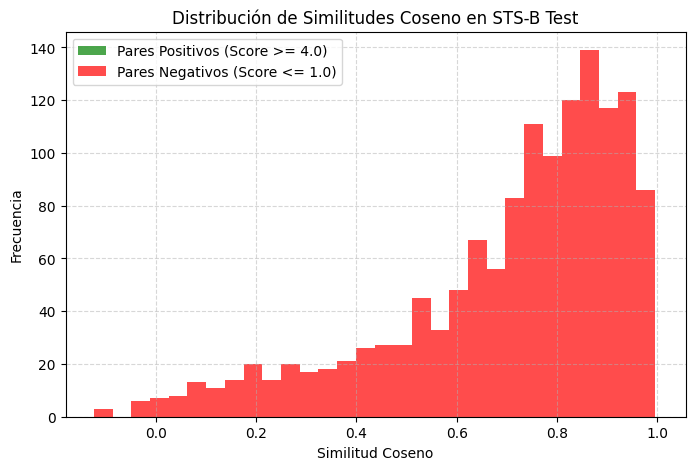

In [7]:
import matplotlib.pyplot as plt

# Separar pares positivos (score >= 4.0) y negativos (score <= 1.0)
pos_mask = np.array(true_scores) >= 4.0
neg_mask = np.array(true_scores) <= 1.0

pos_sims = cos_sims[pos_mask]
neg_sims = cos_sims[neg_mask]

plt.figure(figsize=(8, 5))
plt.hist(pos_sims, bins=30, alpha=0.7, label='Pares Positivos (Score >= 4.0)', color='green')
plt.hist(neg_sims, bins=30, alpha=0.7, label='Pares Negativos (Score <= 1.0)', color='red')
plt.title('Distribución de Similitudes Coseno en STS-B Test')
plt.xlabel('Similitud Coseno')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
import os
from huggingface_hub import login

print("\n=======================================================")
print("PARTE 7: EXPORTACIÓN PARA HUGGING FACE HUB")
print("=======================================================")

# 1. Guardar modelo y tokenizador localmente
save_directory = "./simcse-bert-base-supervised"
model_sup.bert.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"Modelo y Tokenizer guardados localmente en: '{save_directory}'")

# 2. Subir a Hugging Face Hub (Opcional - Requiere Token de HF)
# Para publicar, descomenta las líneas de abajo y pon tu token:
# login(token="TU_TOKEN_HF_AQUÍ")
# model_sup.bert.push_to_hub("tu-usuario/simcse-bert-base-supervised-snli")
# tokenizer.push_to_hub("tu-usuario/simcse-bert-base-supervised-snli")


PARTE 7: EXPORTACIÓN PARA HUGGING FACE HUB


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo y Tokenizer guardados localmente en: './simcse-bert-base-supervised'
